# Análise dos Experimentos de Buffer

Este notebook analisa os resultados gerados por `scripts/run_buffer_benchmark.bat` em `resultados_execucao.csv`.

O objetivo é comparar as políticas `LRU`, `LRUK`, `MRU` e `FIFO` em diferentes tamanhos de buffer, observando tempo de execução, taxa de acerto, misses e comportamento por query.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path("resultados_execucao.csv")

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

policy_order = ["LRU", "LRUK", "MRU", "FIFO"]
policy_colors = {
    "LRU": "#2563eb",
    "LRUK": "#dc2626",
    "MRU": "#16a34a",
    "FIFO": "#9333ea",
}

## 1. Carregamento e validação

A primeira etapa garante que o arquivo foi lido corretamente e que as estatísticas de buffer estão consistentes (`hit_count + miss_count == operation_count`).

In [24]:
df = pd.read_csv(CSV_PATH)

# Normaliza campos auxiliares.
df["error"] = df["error"].fillna("")
df["policy"] = pd.Categorical(df["policy"], categories=policy_order, ordered=True)
df["miss_ratio_percent"] = 100 - df["hit_ratio_percent"]

print(f"Linhas: {len(df)}")
print(f"Políticas: {list(df['policy'].dropna().unique())}")
print(f"Buffer sizes: {sorted(df['buffer_size'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
print(f"Estatísticas válidas: {df['valid_stats'].all()}")

if not df["valid_stats"].all():
    display(df.loc[~df["valid_stats"], ["policy", "buffer_size", "query", "hit_count", "miss_count", "operation_count"]])

df.head()

Linhas: 144
Políticas: ['LRU', 'LRUK', 'MRU', 'FIFO']
Buffer sizes: [np.int64(32), np.int64(64), np.int64(128), np.int64(256)]
Queries: ['q01', 'q02', 'q03', 'q04', 'q05', 'q06', 'q07', 'q08', 'q09']
Estatísticas válidas: True


,policy,buffer_size,repetition,query,elapsed_ms,result_rows,hit_count,miss_count,operation_count,hit_ratio_percent,pages_in_buffer,valid_stats,error,miss_ratio_percent
0,LRU,32,1,q01,35,8,12,2,14,85.7143,2,True,,14.2857
1,LRU,32,1,q02,0,30,36,3,39,92.3077,5,True,,7.6923
2,LRU,32,1,q03,42,52,593,6,599,98.9983,11,True,,1.0017
3,LRU,32,1,q04,16,11,287,296,583,49.2281,32,True,,50.7719
4,LRU,32,1,q05,50,47,1467,3028,4495,32.6363,32,True,,67.3637


## 2. Visão geral por política e tamanho de buffer

A tabela abaixo resume as métricas principais agregadas por política e tamanho de buffer.

In [16]:
summary = (
    df.groupby(["policy", "buffer_size"], observed=True)
    .agg(
        elapsed_total_ms=("elapsed_ms", "sum"),
        elapsed_mean_ms=("elapsed_ms", "mean"),
        hit_ratio_mean=("hit_ratio_percent", "mean"),
        miss_total=("miss_count", "sum"),
        hit_total=("hit_count", "sum"),
        operations_total=("operation_count", "sum"),
        rows_total=("result_rows", "sum"),
    )
    .reset_index()
)

summary["hit_ratio_weighted"] = 100 * summary["hit_total"] / summary["operations_total"]
summary.sort_values(["buffer_size", "policy"])

,policy,buffer_size,elapsed_total_ms,elapsed_mean_ms,hit_ratio_mean,miss_total,hit_total,operations_total,rows_total,hit_ratio_weighted
0,LRU,32,588,65.333333,71.331589,27955,41013,68968,2176,59.466709
4,LRUK,32,1172,130.222222,62.071000,38972,29996,68968,2176,43.492634
8,MRU,32,1071,119.000000,65.180556,36299,32669,68968,2176,47.368345
12,FIFO,32,634,70.444444,71.170356,28135,40833,68968,2176,59.205719
1,LRU,64,635,70.555556,71.481089,27707,41261,68968,2176,59.826296
5,LRUK,64,1115,123.888889,63.537589,38727,30241,68968,2176,43.847871
9,MRU,64,1108,123.111111,66.541244,36107,32861,68968,2176,47.646735
13,FIFO,64,682,75.777778,71.387211,27806,41162,68968,2176,59.682751
2,LRU,128,643,71.444444,75.554789,27190,41778,68968,2176,60.575919
6,LRUK,128,1090,121.111111,66.605500,38248,30720,68968,2176,44.542396


## 3. Tempo total por política

Menor é melhor. Este gráfico soma o tempo das queries para cada combinação de política e tamanho de buffer.

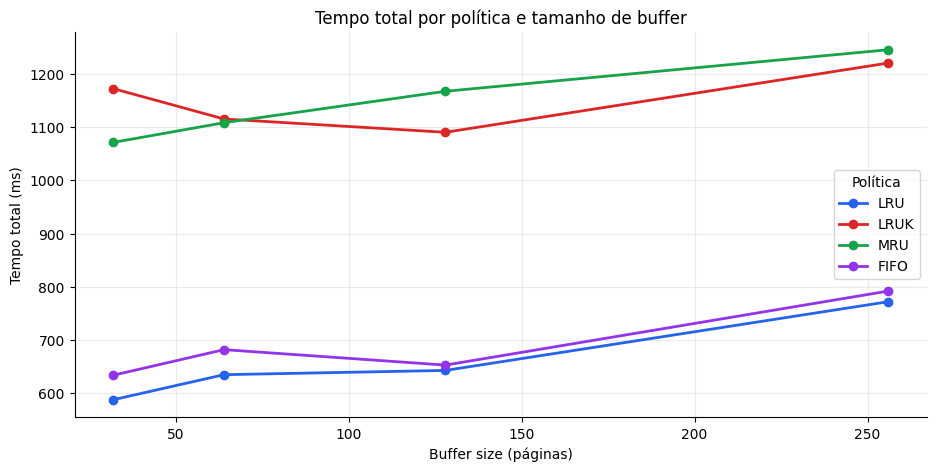

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
for policy in policy_order:
    data = summary[summary["policy"] == policy]
    ax.plot(
        data["buffer_size"],
        data["elapsed_total_ms"],
        marker="o",
        linewidth=2,
        label=policy,
        color=policy_colors[policy],
    )

ax.set_title("Tempo total por política e tamanho de buffer")
ax.set_xlabel("Buffer size (páginas)")
ax.set_ylabel("Tempo total (ms)")
ax.legend(title="Política")
plt.show()

## 4. Hit ratio ponderado

O hit ratio ponderado usa o total de hits e operações, evitando que queries pequenas tenham o mesmo peso que queries grandes.

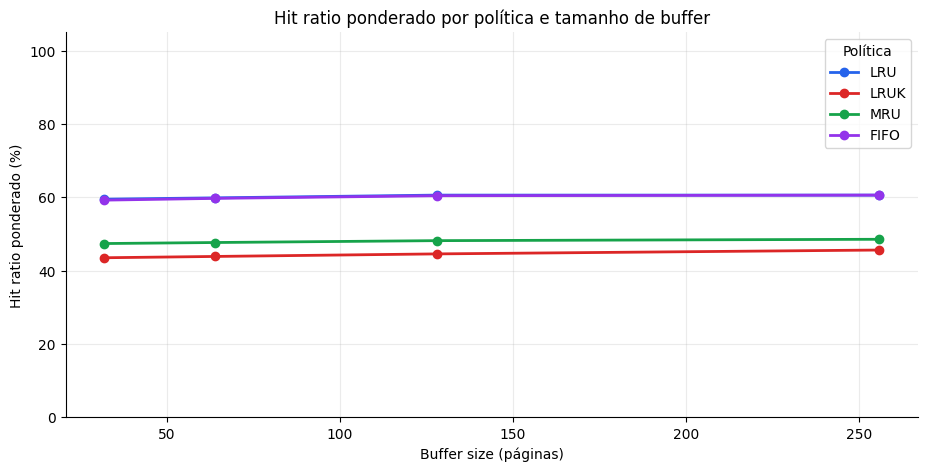

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
for policy in policy_order:
    data = summary[summary["policy"] == policy]
    ax.plot(
        data["buffer_size"],
        data["hit_ratio_weighted"],
        marker="o",
        linewidth=2,
        label=policy,
        color=policy_colors[policy],
    )

ax.set_title("Hit ratio ponderado por política e tamanho de buffer")
ax.set_xlabel("Buffer size (páginas)")
ax.set_ylabel("Hit ratio ponderado (%)")
ax.set_ylim(0, 105)
ax.legend(title="Política")
plt.show()

## 5. Misses totais

Misses indicam acessos que precisaram buscar página fora do buffer. Menor é melhor.

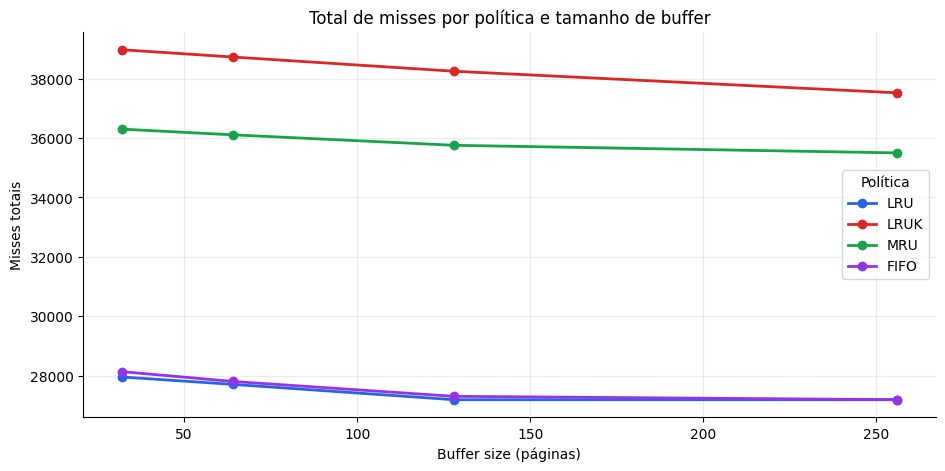

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
for policy in policy_order:
    data = summary[summary["policy"] == policy]
    ax.plot(
        data["buffer_size"],
        data["miss_total"],
        marker="o",
        linewidth=2,
        label=policy,
        color=policy_colors[policy],
    )

ax.set_title("Total de misses por política e tamanho de buffer")
ax.set_xlabel("Buffer size (páginas)")
ax.set_ylabel("Misses totais")
ax.legend(title="Política")
plt.show()

## 6. Comparaçãoo por query

Aqui vemos onde cada política se comportou melhor ou pior. O foco está no `hit_ratio_percent` por query.

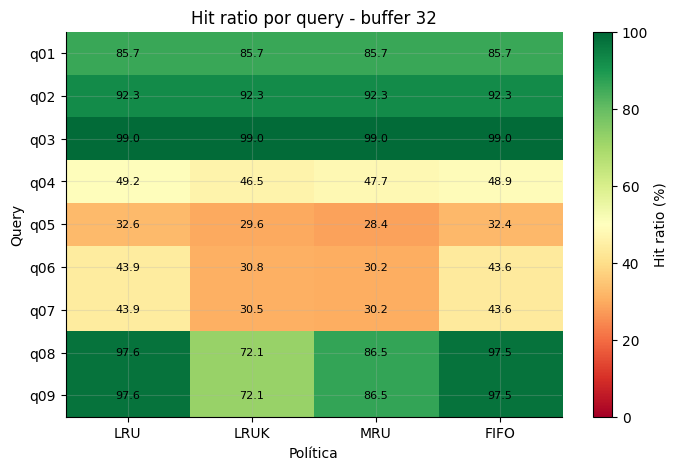

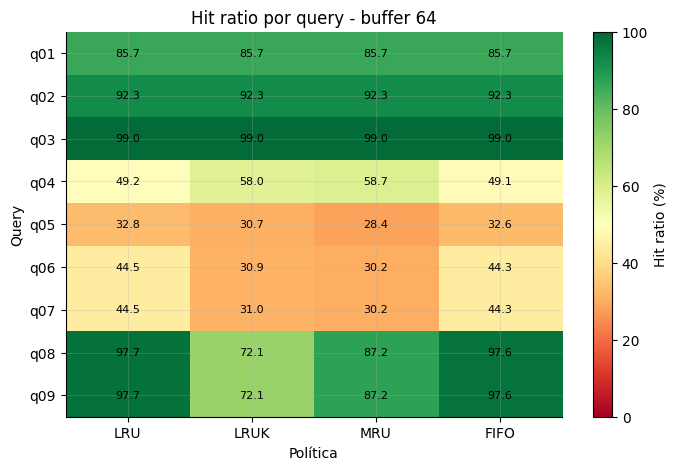

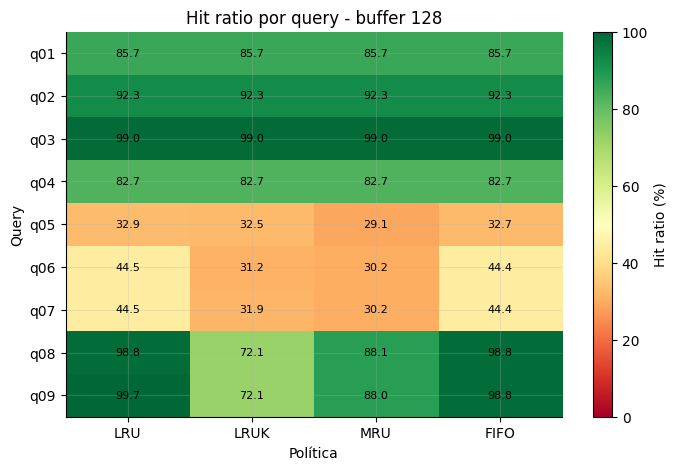

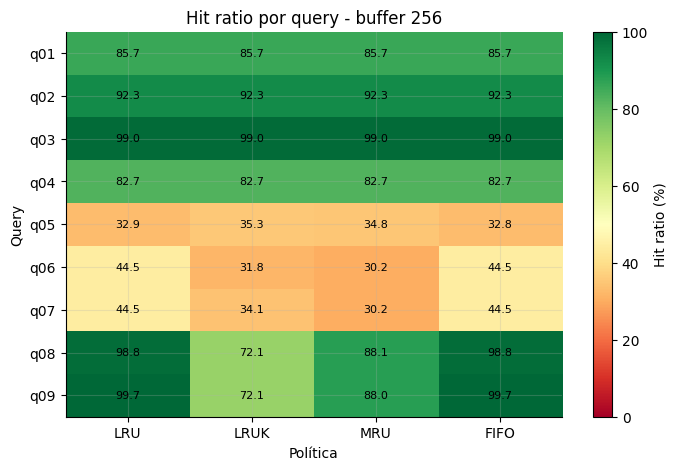

In [20]:
for buffer_size in sorted(df["buffer_size"].unique()):
    pivot = (
        df[df["buffer_size"] == buffer_size]
        .pivot_table(index="query", columns="policy", values="hit_ratio_percent", observed=True)
        .reindex(columns=policy_order)
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_title(f"Hit ratio por query - buffer {buffer_size}")
    ax.set_xlabel("Política")
    ax.set_ylabel("Query")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label="Hit ratio (%)")
    plt.show()

## 7. Ranking geral

Ranking por tempo total e por hit ratio ponderado. Em geral, o melhor algoritmo para o experimento é aquele que combina menor tempo com menor n?mero de misses.

In [21]:
overall = (
    df.groupby("policy", observed=True)
    .agg(
        elapsed_total_ms=("elapsed_ms", "sum"),
        elapsed_mean_ms=("elapsed_ms", "mean"),
        hit_total=("hit_count", "sum"),
        miss_total=("miss_count", "sum"),
        operations_total=("operation_count", "sum"),
    )
    .reset_index()
)
overall["hit_ratio_weighted"] = 100 * overall["hit_total"] / overall["operations_total"]
overall["rank_time"] = overall["elapsed_total_ms"].rank(method="min")
overall["rank_hit_ratio"] = overall["hit_ratio_weighted"].rank(method="min", ascending=False)
overall["rank_misses"] = overall["miss_total"].rank(method="min")
overall["rank_average"] = overall[["rank_time", "rank_hit_ratio", "rank_misses"]].mean(axis=1)

overall.sort_values("rank_average")

,policy,elapsed_total_ms,elapsed_mean_ms,hit_total,miss_total,operations_total,hit_ratio_weighted,rank_time,rank_hit_ratio,rank_misses,rank_average
0,LRU,2638,73.277778,165830,110042,275872,60.111211,1.0,1.0,1.0,1.0
3,FIFO,2761,76.694444,165435,110437,275872,59.968029,2.0,2.0,2.0,2.0
2,MRU,4591,127.527778,132212,143660,275872,47.925125,3.0,3.0,3.0,3.0
1,LRUK,4597,127.694444,122404,153468,275872,44.369853,4.0,4.0,4.0,4.0


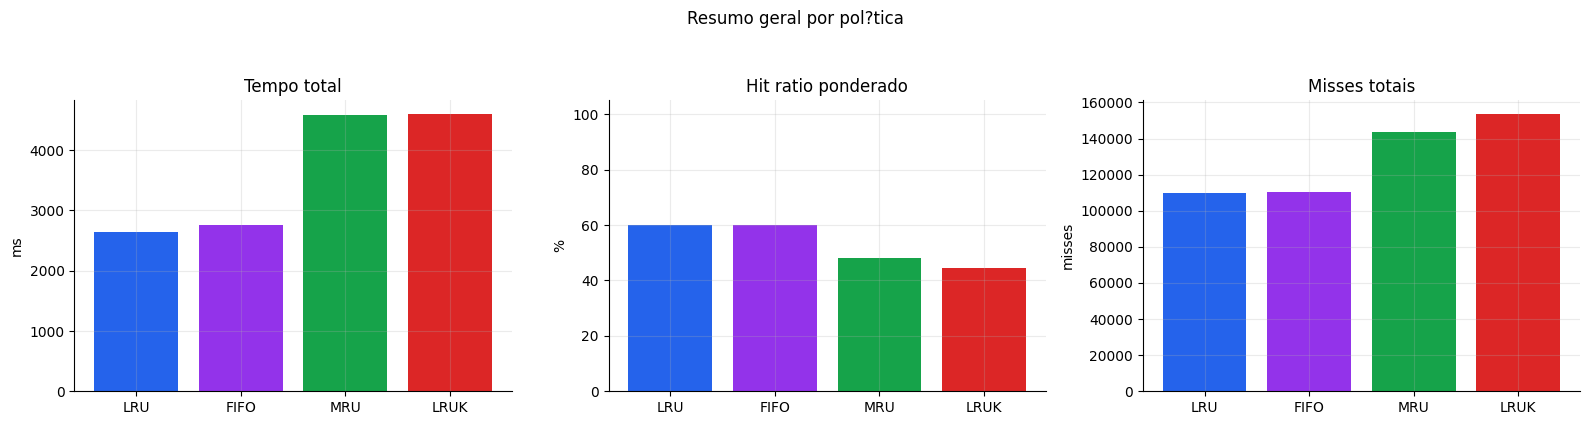

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ordered = overall.sort_values("rank_average")
colors = [policy_colors[str(policy)] for policy in ordered["policy"]]

axes[0].bar(ordered["policy"].astype(str), ordered["elapsed_total_ms"], color=colors)
axes[0].set_title("Tempo total")
axes[0].set_ylabel("ms")

axes[1].bar(ordered["policy"].astype(str), ordered["hit_ratio_weighted"], color=colors)
axes[1].set_title("Hit ratio ponderado")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 105)

axes[2].bar(ordered["policy"].astype(str), ordered["miss_total"], color=colors)
axes[2].set_title("Misses totais")
axes[2].set_ylabel("misses")

fig.suptitle("Resumo geral por pol?tica", y=1.05)
plt.tight_layout()
plt.show()

## 8. Leituras rápidas

Use estas células para gerar frases objetivas para o relatório.

In [23]:
best_time = overall.sort_values("elapsed_total_ms").iloc[0]
best_hit = overall.sort_values("hit_ratio_weighted", ascending=False).iloc[0]
best_misses = overall.sort_values("miss_total").iloc[0]

print(f"Menor tempo total: {best_time['policy']} ({best_time['elapsed_total_ms']} ms)")
print(f"Maior hit ratio ponderado: {best_hit['policy']} ({best_hit['hit_ratio_weighted']:.2f}%)")
print(f"Menor total de misses: {best_misses['policy']} ({best_misses['miss_total']} misses)")

print("\nResumo ordenado pelo ranking combinado:")
display(overall.sort_values("rank_average")[[
    "policy", "elapsed_total_ms", "hit_ratio_weighted", "miss_total", "rank_average"
]])

Menor tempo total: LRU (2638 ms)
Maior hit ratio ponderado: LRU (60.11%)
Menor total de misses: LRU (110042 misses)

Resumo ordenado pelo ranking combinado:


,policy,elapsed_total_ms,hit_ratio_weighted,miss_total,rank_average
0,LRU,2638,60.111211,110042,1.0
3,FIFO,2761,59.968029,110437,2.0
2,MRU,4591,47.925125,143660,3.0
1,LRUK,4597,44.369853,153468,4.0
